<a href="https://colab.research.google.com/github/mohit-kumar396/Machine-Learning-Project/blob/main/Employee_Attrition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Problem Satement**

**Employee attrition (employees leaving a company) is a major concern for organizations as it increases recruitment and training costs.**
**The goal is to analyze employee data, find patterns that lead to attrition, and build a machine learning model to predict whether
an employee will leave or stay.**

#**Objectives**

- Perform Exploratory Data Analysis (EDA) to identify the key factors influencing employee attrition.
- Apply feature engineering techniques to improve model performance.
- Build and evaluate Machine Learning models such as:
  - Logistic Regression
  - Random Forest
  - XGBoost
  - Other suitable classification models
- Compare model performance using appropriate evaluation metrics.
- Identify important features contributing to employee attrition.
- Provide actionable business insights and recommendations to help reduce employee attrition.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

##**Dataset Overview**

**Dataset:** IBM HR Analytics Employee Attrition Dataset

This dataset contains employee-level HR records used to predict whether an employee is likely to leave the company (attrition).

##**Features**

| Feature | Description |
|---|---|
| **Age** | Age of the employee |
| **JobRole** | Employee's job role/designation |
| **MonthlyIncome** | Monthly salary of the employee |
| **Education** | Education level (numeric scale) |
| **WorkLifeBalance** | Work-life balance rating (numeric scale) |
| **YearsAtCompany** | Number of years spent at the current company |
| **OverTime** | Whether the employee works overtime (Yes/No) etc. |

**Target Variable**

**`Attrition`** — Whether the employee has left the company
- `Yes` → Employee left
- `No` → Employee stayed

**Objective**

Build a classification model to predict employee attrition based on HR and demographic features, helping identify key factors that drive employees to leave.

In [ ]:
# Load dataset
df = pd.read_csv("Attrition_Dataset.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
df[['DailyRate', 'HourlyRate', 'MonthlyRate', 'MonthlyIncome']].corr()

,DailyRate,HourlyRate,MonthlyRate,MonthlyIncome
DailyRate,1.000000,0.023381,-0.032182,0.007707
HourlyRate,0.023381,1.000000,-0.015297,-0.015794
MonthlyRate,-0.032182,-0.015297,1.000000,0.034814
MonthlyIncome,0.007707,-0.015794,0.034814,1.000000


In [ ]:
# Check missing values

print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [ ]:
# Check Attrition Counts.

df['Attrition'].value_counts()

,count
Attrition,
0,1233
1,237


In [ ]:
if df['Attrition'].dtype == object:
    le = LabelEncoder()
    df['Attrition'] = le.fit_transform(df['Attrition'])

In [ ]:
df['Attrition'].value_counts()

,count
Attrition,
0,1233
1,237


In [ ]:
categorical_cols= df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [ ]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
#Checking Unique Value in every coulmn

for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

BusinessTravel: [2 1 0]
Department: [2 1 0]
EducationField: [1 4 3 2 5 0]
Gender: [0 1]
JobRole: [7 6 2 4 0 3 8 5 1]
MaritalStatus: [2 1 0]
Over18: [0]
OverTime: [1 0]


In [ ]:
# Feature scaling
from sklearn.preprocessing import StandardScaler

# Separate target first
y = df['Attrition']

# Features only (exclude target)
X = df.drop(columns=['Attrition'])

# Scale only numeric feature columns
scaler = StandardScaler()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
X[num_cols] = scaler.fit_transform(X[num_cols])


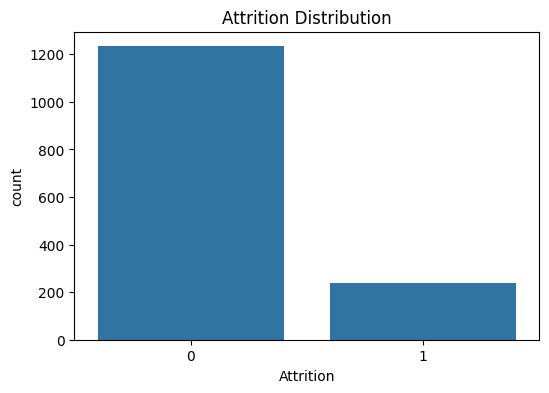

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)
plt.title("Attrition Distribution")
plt.show()


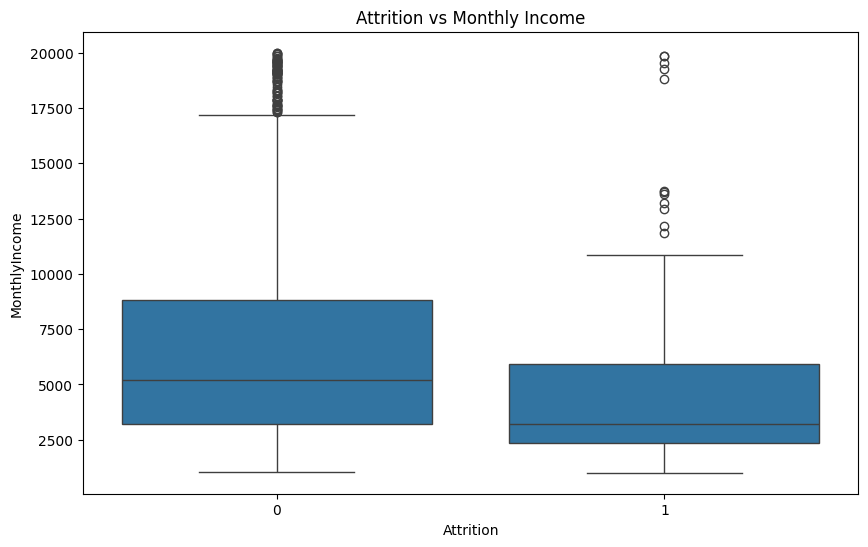

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title("Attrition vs Monthly Income")
plt.show()

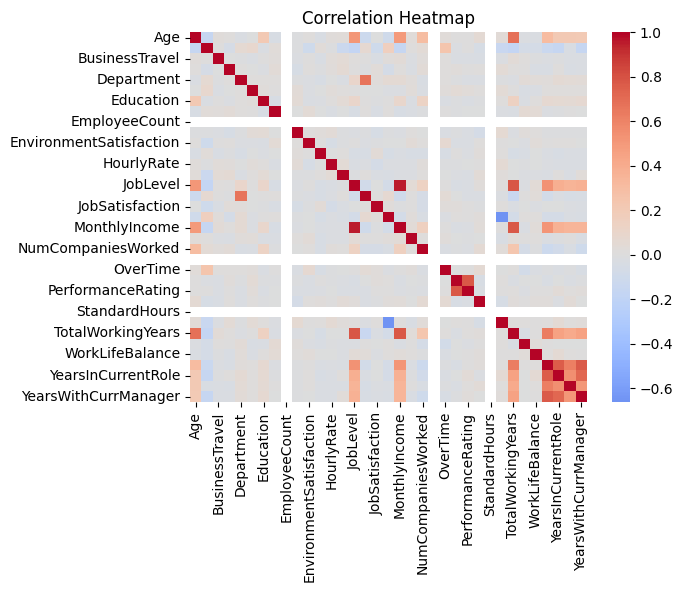

In [ ]:
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
print(df['Attrition'].unique())
print(df['Attrition'].dtype)


[1 0]
int64


In [ ]:
# Target must be Attrition only
y = df['Attrition'].astype(int)

# Features are all other columns
X = df.drop(columns=['Attrition'])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# stratify=y forces the split to preserve the same class proportions in both train and test sets
print("y_train unique values:", y_train.unique())

y_train unique values: [0 1]


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr)*100)
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 58.843537414965986
              precision    recall  f1-score   support

           0       0.88      0.59      0.71       247
           1       0.22      0.60      0.32        47

    accuracy                           0.59       294
   macro avg       0.55      0.59      0.51       294
weighted avg       0.78      0.59      0.64       294



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8299319727891157
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.38      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.62      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294



In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8639455782312925
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       247
           1       0.71      0.26      0.38        47

    accuracy                           0.86       294
   macro avg       0.79      0.62      0.65       294
weighted avg       0.85      0.86      0.84       294



/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [05:31:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Logistic Regression Accuracy: 0.5884353741496599


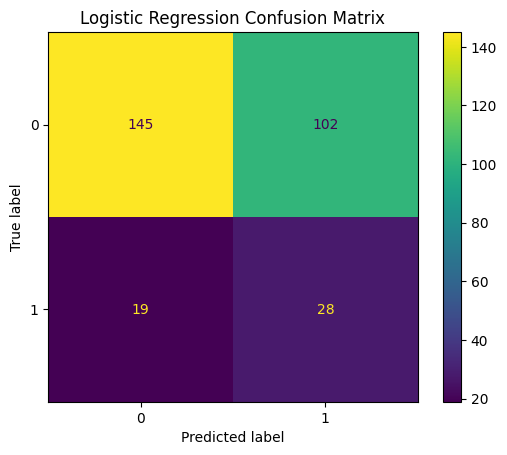


Random Forest Accuracy: 0.8299319727891157


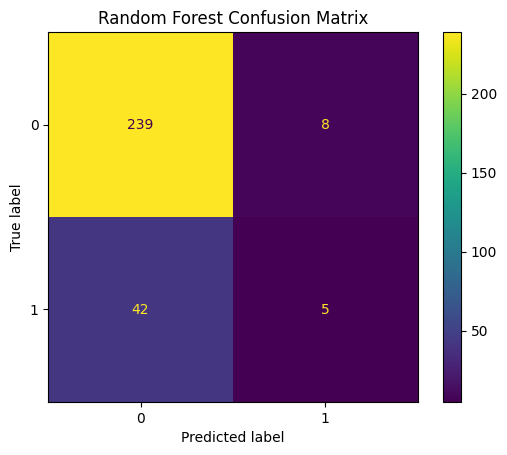


XGBoost Accuracy: 0.8639455782312925


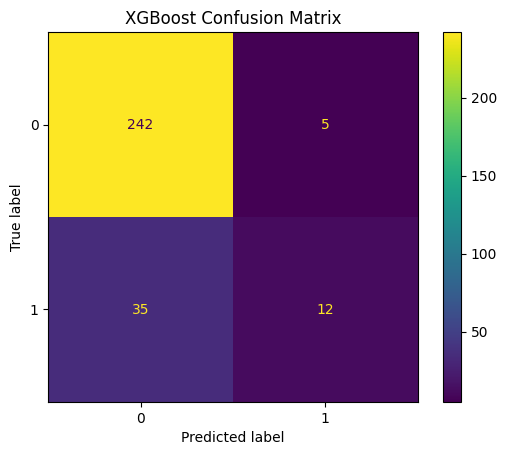

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

models = {'Logistic Regression': y_pred_lr,
          'Random Forest': y_pred_rf,
          'XGBoost': y_pred_xgb}

for name, preds in models.items():
    print(f"\n{name} Accuracy: {accuracy_score(y_test, preds)}")
    ConfusionMatrixDisplay.from_predictions(y_test, preds)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

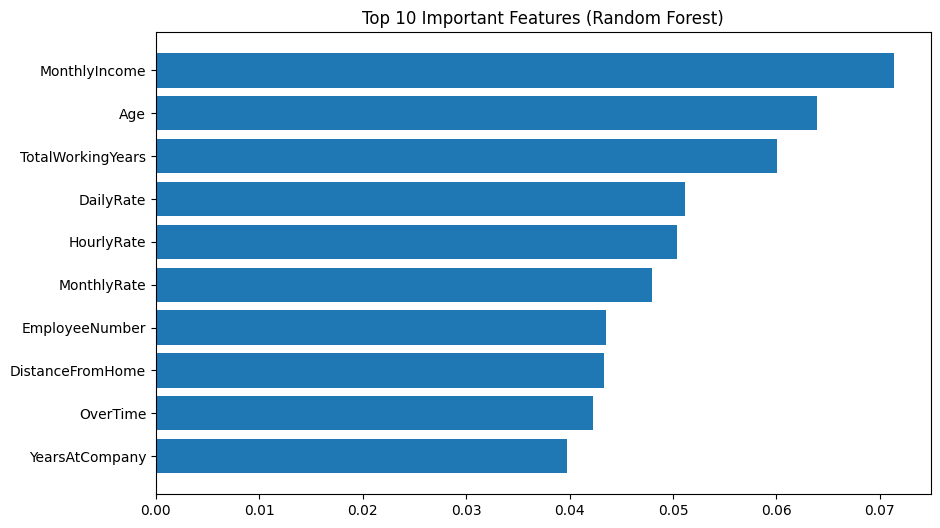

In [ ]:
importances = rf.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.title("Top 10 Important Features (Random Forest)")
plt.show()